# 08. External Validation — CheXpert (Domain Shift 분석)

## 목적
NIH ChestX-ray14로 학습한 모델을 **Stanford CheXpert** 데이터셋에 적용해  
도메인 시프트(Domain Shift) 크기를 정량화합니다.

## NIH ↔ CheXpert 공통 클래스 (7개)
| NIH 레이블 | CheXpert 컬럼 |
|-----------|---------------|
| Atelectasis | Atelectasis |
| Cardiomegaly | Cardiomegaly |
| Consolidation | Consolidation |
| Edema | Edema |
| Effusion | Pleural Effusion |
| Pneumonia | Pneumonia |
| Pneumothorax | Pneumothorax |

## Uncertain(-1) 처리
기본: **U-zeros** (−1 → 0, 보수적 평가)

In [1]:
# ── 1. 환경 및 경로 자동 설정 ──────────────────────────────────────────────
import os
import sys
from pathlib import Path

# 노트북이 위치한 폴더를 기준으로 프로젝트 최상위 폴더를 자동으로 찾습니다.
current_path = Path(os.getcwd()).resolve()
if current_path.name == "notebooks":
    PROJECT_DIR = current_path.parent
else:
    PROJECT_DIR = current_path

# 작업 디렉토리 강제 변경
os.chdir(PROJECT_DIR)
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

print(f"현재 작업 폴더가 설정되었습니다: {os.getcwd()}")

현재 작업 폴더가 설정되었습니다: C:\CSE4187\CXR-CAD


In [2]:
# ── 2. 라이브러리 임포트 및 변수 설정 ───────────────────────────────────────
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import yaml

# 커스텀 모듈 임포트
from src.preprocess.chexpert_loader import build_chexpert_val_loader, EVAL_LABELS
from src.preprocess.transforms import get_inference_transforms
from src.train.models import build_model, DISEASE_LABELS
from src.analysis.evaluation import compute_auroc, compute_auprc
from src.analysis.external_val import compare_internal_external

# config.yaml 로드
config_path = Path('configs/config.yaml')
if not config_path.exists():
    print(f"설정 파일을 찾을 수 없습니다: {config_path.absolute()}")
else:
    with open(config_path, encoding='utf-8') as f:
        CFG = yaml.safe_load(f)
    print("config.yaml 로드 성공")

# 평가할 모델 3개
MODELS_TO_EVAL = ['densenet', 'efficientnet', 'vit']

# CheXpert 경로 자동 매핑 (프로젝트 내 data/chexpert/CheXpert-v1.0-small)
CHEXPERT_ROOT = Path("data") / "chexpert" / "CheXpert-v1.0-small"

# 기타 파라미터
IMAGE_SIZE = CFG['data']['image_size']
UNCERTAIN = CFG['chexpert']['uncertain_strategy']  
EVAL_SPLIT = CFG['chexpert']['eval_split']         
BATCH_SIZE = CFG['train']['batch_size']
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"CheXpert 탐색 경로: {CHEXPERT_ROOT.absolute()}")

config.yaml 로드 성공
CheXpert 탐색 경로: C:\CSE4187\CXR-CAD\data\chexpert\CheXpert-v1.0-small


In [3]:
# ── 3. CheXpert 데이터 로드 ────────────────────────────────────────────────
csv_check = CHEXPERT_ROOT / f"{EVAL_SPLIT}.csv"

if not csv_check.exists():
    print(f"CheXpert 데이터를 찾을 수 없습니다: {csv_check.absolute()}")
    print("데이터셋 압축을 제대로 풀었는지, 폴더 이름이 맞는지 확인해주세요.")
else:
    print("CheXpert 데이터가 확인되었습니다. 로딩을 시작합니다...")
    chex_loader, eval_labels = build_chexpert_val_loader(
        chexpert_root=str(CHEXPERT_ROOT),
        split=EVAL_SPLIT,
        uncertain_strategy=UNCERTAIN,
        transform=get_inference_transforms(IMAGE_SIZE),
        batch_size=BATCH_SIZE,
        num_workers=0, # 윈도우 환경 병렬 로딩 에러 방지
    )
    print(f"\n데이터 로드 완료! 평가 라벨 ({len(eval_labels)}개): {eval_labels}")

CheXpert 데이터가 확인되었습니다. 로딩을 시작합니다...
[CheXpert] valid.csv 로드 완료
  총 샘플: 202 (uncertain_strategy=u_zeros, frontal_only=True)

데이터 로드 완료! 평가 라벨 (7개): ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Pneumonia', 'Pneumothorax']



[densenet_best] 도메인 시프트 검증 시작


c:\Python\lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


densenet_best Inference:   0%|          | 0/7 [00:00<?, ?it/s]


[ densenet_best 비교 결과 ]
      Disease  NIH AUROC  CheXpert AUROC    Gap
  Atelectasis     0.8256          0.8124  -1.3%
 Cardiomegaly     0.9242          0.7801 -14.4%
Consolidation     0.8268          0.8814  +5.5%
        Edema     0.9236          0.8125 -11.1%
     Effusion     0.8962          0.8784  -1.8%
    Pneumonia     0.7714          0.7403  -3.1%
 Pneumothorax     0.8993          0.8593  -4.0%
    macro_avg     0.8667          0.8235  -4.3%


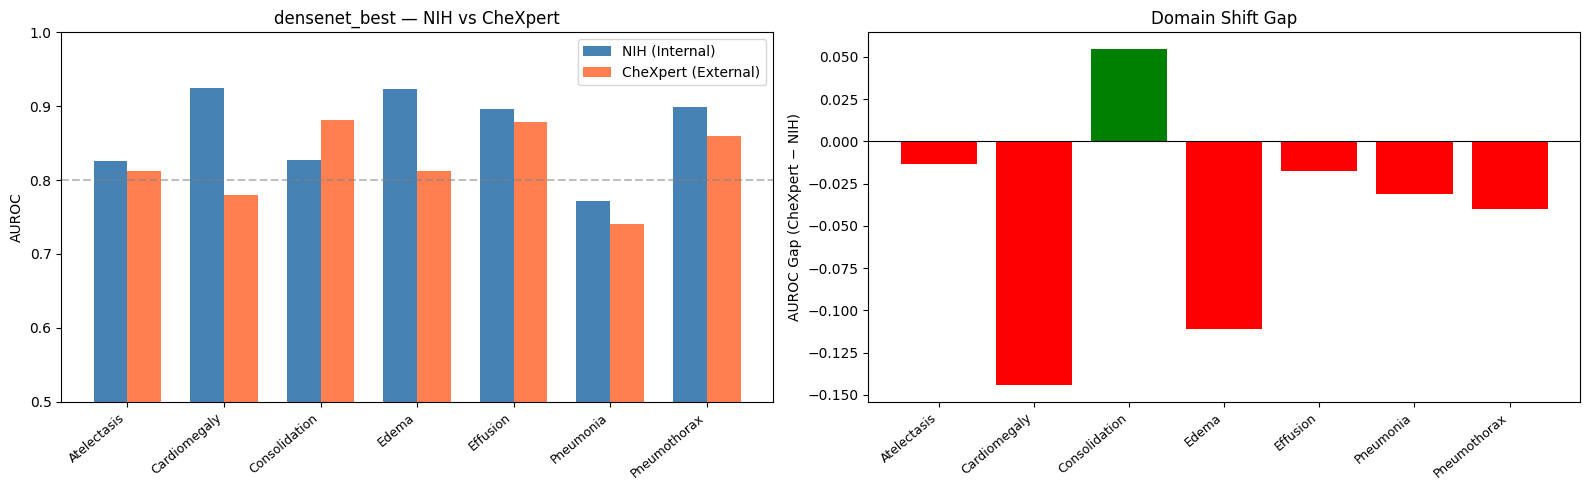

densenet_best 산출물 저장 완료: checkpoints\densenet\densenet_best_domain_shift.png


[efficientnet_fold1_best] 도메인 시프트 검증 시작


c:\Python\lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


efficientnet_fold1_best Inference:   0%|          | 0/7 [00:00<?, ?it/s]


[ efficientnet_fold1_best 비교 결과 ]
      Disease  NIH AUROC  CheXpert AUROC    Gap
  Atelectasis     0.8256          0.7236 -10.2%
 Cardiomegaly     0.9242          0.8203 -10.4%
Consolidation     0.8268          0.8171  -1.0%
        Edema     0.9236          0.7622 -16.1%
     Effusion     0.8962          0.8153  -8.1%
    Pneumonia     0.7714          0.7307  -4.1%
 Pneumothorax     0.8993          0.6205 -27.9%
    macro_avg     0.8667          0.7557 -11.1%


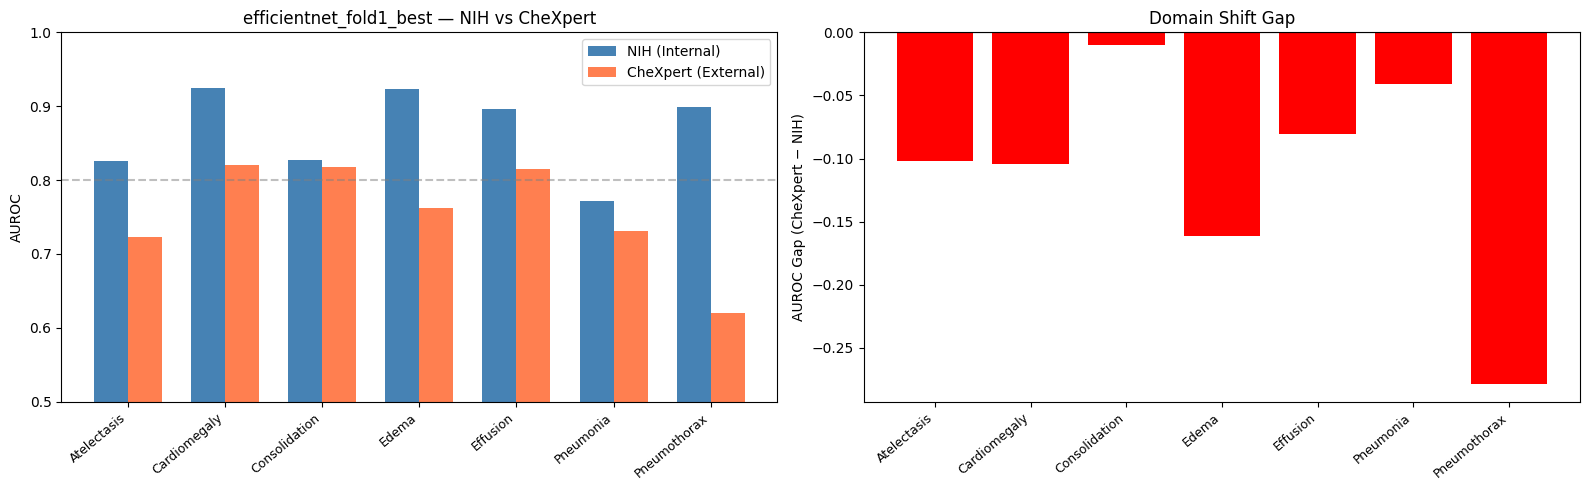

efficientnet_fold1_best 산출물 저장 완료: checkpoints\efficientnet\efficientnet_fold1_best_domain_shift.png


[efficientnet_fold2_best] 도메인 시프트 검증 시작


c:\Python\lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


efficientnet_fold2_best Inference:   0%|          | 0/7 [00:00<?, ?it/s]


[ efficientnet_fold2_best 비교 결과 ]
      Disease  NIH AUROC  CheXpert AUROC    Gap
  Atelectasis     0.8256          0.7186 -10.7%
 Cardiomegaly     0.9242          0.7718 -15.2%
Consolidation     0.8268          0.8388  +1.2%
        Edema     0.9236          0.7561 -16.8%
     Effusion     0.8962          0.8089  -8.7%
    Pneumonia     0.7714          0.8067  +3.5%
 Pneumothorax     0.8993          0.7319 -16.7%
    macro_avg     0.8667          0.7761  -9.1%


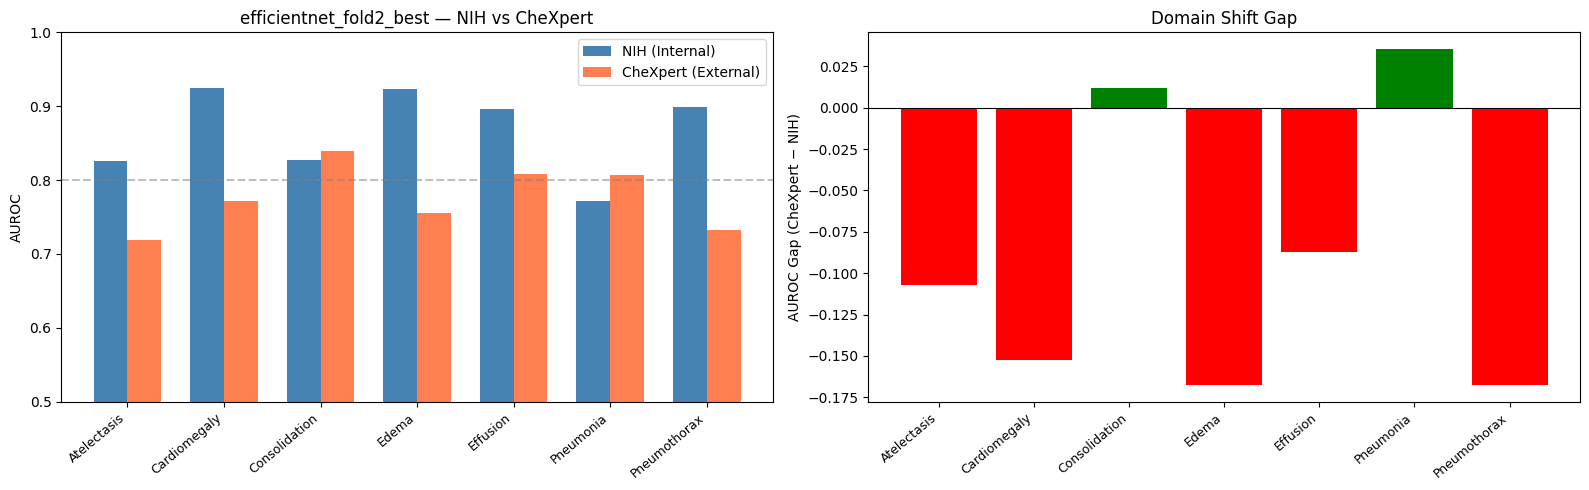

efficientnet_fold2_best 산출물 저장 완료: checkpoints\efficientnet\efficientnet_fold2_best_domain_shift.png


[vit_fold1_best] 도메인 시프트 검증 시작


c:\Python\lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


vit_fold1_best Inference:   0%|          | 0/7 [00:00<?, ?it/s]


[ vit_fold1_best 비교 결과 ]
      Disease  NIH AUROC  CheXpert AUROC    Gap
  Atelectasis     0.8256          0.7756  -5.0%
 Cardiomegaly     0.9242          0.7780 -14.6%
Consolidation     0.8268          0.8993  +7.2%
        Edema     0.9236          0.8211 -10.3%
     Effusion     0.8962          0.8406  -5.6%
    Pneumonia     0.7714          0.7004  -7.1%
 Pneumothorax     0.8993          0.6586 -24.1%
    macro_avg     0.8667          0.7819  -8.5%


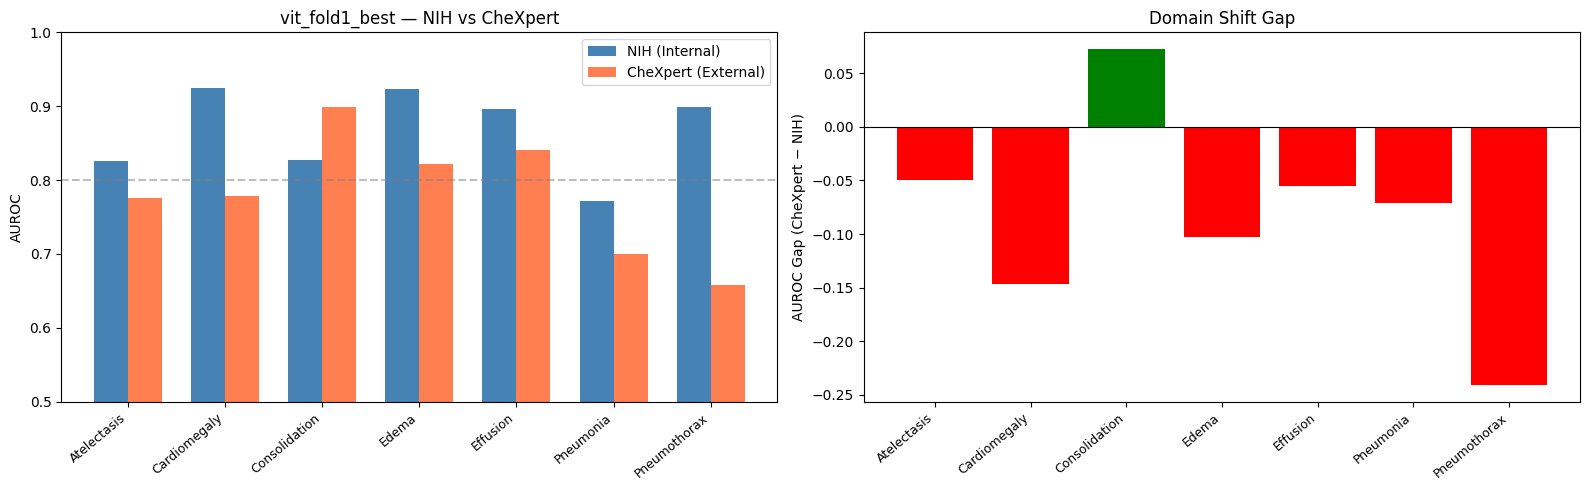

vit_fold1_best 산출물 저장 완료: checkpoints\vit\vit_fold1_best_domain_shift.png


[vit_fold2_best] 도메인 시프트 검증 시작


c:\Python\lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


vit_fold2_best Inference:   0%|          | 0/7 [00:00<?, ?it/s]


[ vit_fold2_best 비교 결과 ]
      Disease  NIH AUROC  CheXpert AUROC    Gap
  Atelectasis     0.8256          0.8008  -2.5%
 Cardiomegaly     0.9242          0.8330  -9.1%
Consolidation     0.8268          0.8504  +2.4%
        Edema     0.9236          0.7937 -13.0%
     Effusion     0.8962          0.8370  -5.9%
    Pneumonia     0.7714          0.6501 -12.1%
 Pneumothorax     0.8993          0.7604 -13.9%
    macro_avg     0.8667          0.7894  -7.7%


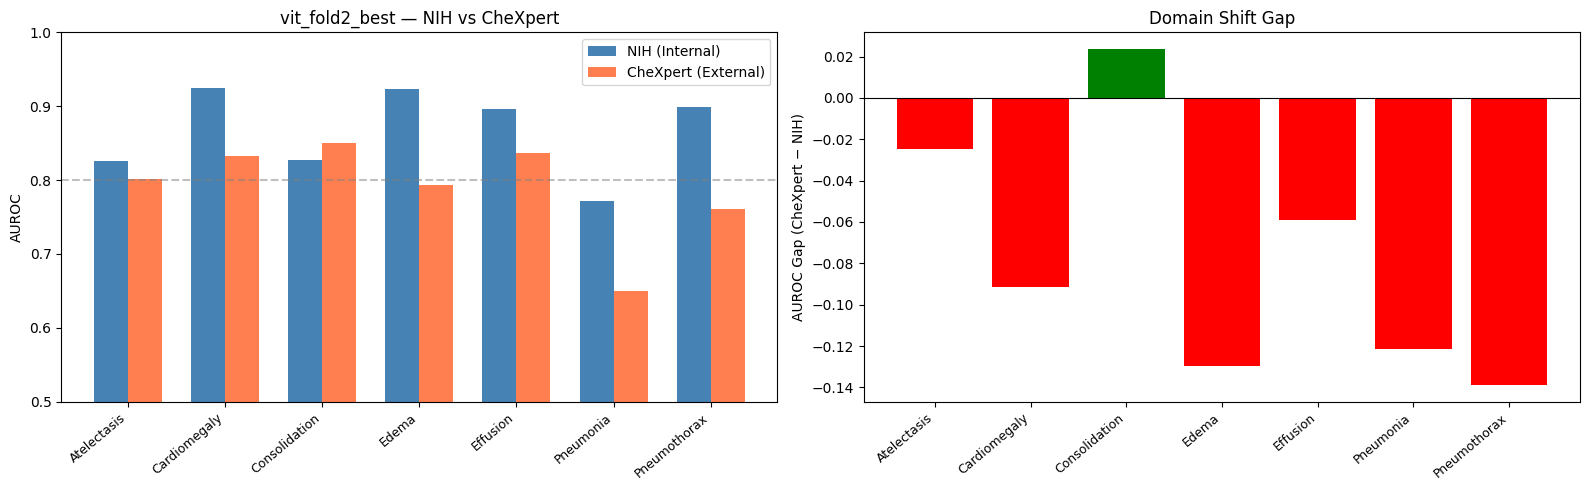

vit_fold2_best 산출물 저장 완료: checkpoints\vit\vit_fold2_best_domain_shift.png



In [ ]:
# ── 4. 다중 모델 및 폴드(Fold) 순차 검증 및 결과 자동 저장 ────────────────────────
eval_indices = [DISEASE_LABELS.index(l) for l in EVAL_LABELS]

for model_key in MODELS_TO_EVAL:
    CHECKPOINT_DIR = Path("checkpoints") / model_key
    
    # 해당 모델 폴더 내의 모든 .pth 파일을 자동으로 모두 찾습니다.
    ckpt_files = list(CHECKPOINT_DIR.glob("*.pth"))
    
    if not ckpt_files:
        print(f"\n=================================================================")
        print(f"[{model_key.upper()}] 폴더에 .pth 가중치 파일이 없어 건너뜁니다.")
        print(f"=================================================================")
        continue

    # 찾은 각각의 폴드 가중치 파일에 대해 검증을 진행합니다.
    for CKPT_PATH in ckpt_files:
        ckpt_name = CKPT_PATH.stem # 파일명 추출 (예: efficientnet_fold1_best)
        
        print(f"\n" + "="*65)
        print(f"[{ckpt_name}] 도메인 시프트 검증 시작")
        print("="*65)
        
        # 해당 모델의 내부 검증 결과 파일 (test_predictions.csv) 확인
        NIH_CSV_PATH = CHECKPOINT_DIR / "test_predictions.csv"
        if not NIH_CSV_PATH.exists():
            print(f"'{NIH_CSV_PATH}' 파일이 없습니다. 내부 성능과 비교할 수 없어 건너뜁니다.")
            continue

        # 모델 빌드 및 가중치 로드
        model = build_model(model_key)
        ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=True)
        
        # 파일 저장 방식(딕셔너리 여부)에 따라 유연하게 로드
        state_dict = ckpt.get('model_state_dict', ckpt)
        
        # 멀티 GPU(DataParallel)로 학습되어 'module.'이 붙어있는 경우 강제로 제거
        clean_state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
        
        # 정제된 가중치 로드
        model.load_state_dict(clean_state_dict)
        model.to(DEVICE)
        model.eval()

        # CheXpert 추론
        all_probs, all_targets = [], []
        with torch.no_grad():
            for images, labels in tqdm(chex_loader, desc=f'{ckpt_name} Inference'):
                images = images.to(device=DEVICE, non_blocking=True)
                with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
                    logits = model(images)
                probs = torch.sigmoid(logits).cpu().numpy()
                all_probs.append(probs)
                all_targets.append(labels.numpy())

        y_true_14 = np.concatenate(all_targets, axis=0)
        y_prob_14 = np.concatenate(all_probs, axis=0)

        # CheXpert AUROC 계산
        y_true_7 = y_true_14[:, eval_indices]
        y_prob_7 = y_prob_14[:, eval_indices]
        chex_auroc = compute_auroc(y_true_7, y_prob_7, EVAL_LABELS)
        
        # 내부 NIH AUROC 로드 및 계산
        nih_df = pd.read_csv(NIH_CSV_PATH)
        nih_true_7 = nih_df[[f"{l}_true" for l in EVAL_LABELS]].values
        nih_prob_7 = nih_df[[f"{l}_prob" for l in EVAL_LABELS]].values
        nih_auroc = compute_auroc(nih_true_7, nih_prob_7, EVAL_LABELS)
        
        # 갭(Gap) 계산 및 표 생성
        gap = compare_internal_external(nih_auroc, chex_auroc, EVAL_LABELS)
        rows = []
        for label in EVAL_LABELS:
            rows.append({
                'Disease': label,
                'NIH AUROC': round(nih_auroc.get(label, float('nan')), 4),
                'CheXpert AUROC': round(chex_auroc.get(label, float('nan')), 4),
                'Gap': f"{gap.get(label, float('nan')):+.1%}"
            })
        rows.append({
            'Disease': 'macro_avg',
            'NIH AUROC': round(nih_auroc['macro_avg'], 4),
            'CheXpert AUROC': round(chex_auroc['macro_avg'], 4),
            'Gap': f"{gap['macro_avg']:+.1%}"
        })
        
        cmp_df = pd.DataFrame(rows)
        print(f"\n[ {ckpt_name} 비교 결과 ]")
        print(cmp_df.to_string(index=False))
        
        # 결과 CSV 저장 (파일명에 폴드명 반영)
        save_csv_path = CHECKPOINT_DIR / f"{ckpt_name}_domain_shift.csv"
        cmp_df.to_csv(save_csv_path, index=False)
        
        # 차트 시각화
        nih_vals  = [nih_auroc[l]  for l in EVAL_LABELS]
        chex_vals = [chex_auroc[l] for l in EVAL_LABELS]
        x = range(len(EVAL_LABELS))
        width = 0.35
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
        
        # 첫 번째: Bar chart
        ax = axes[0]
        ax.bar([i - width/2 for i in x], nih_vals,  width, label='NIH (Internal)', color='steelblue')
        ax.bar([i + width/2 for i in x], chex_vals, width, label='CheXpert (External)', color='coral')
        ax.set_xticks(list(x))
        ax.set_xticklabels(EVAL_LABELS, rotation=40, ha='right', fontsize=9)
        ax.set_ylim(0.5, 1.0)
        ax.set_ylabel('AUROC')
        ax.set_title(f'{ckpt_name} — NIH vs CheXpert')
        ax.legend()
        ax.axhline(0.8, color='gray', linestyle='--', alpha=0.5)

        # 두 번째: Gap chart
        ax2 = axes[1]
        gaps = [chex_vals[i] - nih_vals[i] for i in range(len(EVAL_LABELS))]
        colors = ['red' if g < 0 else 'green' for g in gaps]
        ax2.bar(EVAL_LABELS, gaps, color=colors)
        ax2.axhline(0, color='black', linewidth=0.8)
        ax2.set_xticks(range(len(EVAL_LABELS)))
        ax2.set_xticklabels(EVAL_LABELS, rotation=40, ha='right', fontsize=9)
        ax2.set_ylabel('AUROC Gap (CheXpert − NIH)')
        ax2.set_title('Domain Shift Gap')

        plt.tight_layout()
        
        # 차트 PNG 이미지 저장 (파일명에 폴드명 반영)
        save_png_path = CHECKPOINT_DIR / f'{ckpt_name}_domain_shift.png'
        plt.savefig(str(save_png_path), dpi=150)
        plt.show()
        
        print(f"{ckpt_name} 산출물 저장 완료: {save_png_path}\n")